# Exercise 4: Period of an Anharmonic Oscillator


## Setup

In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

A   = 2.0
lam = 1.0

def V(x):
    return 0.5*x**2 + (lam/4)*x**4

E = V(A)
print(f"E = V(A) = {E}")

def f(x):
    """Integrand of the original integral — singular at x = A."""
    return 1.0 / np.sqrt(np.maximum(2*(E - V(x)), 0))

E = V(A) = 6.0


---
## Part 1: Mathematical Analysis of the Singularity

Taylor-expand $V(x)$ around $x = A$:
$$V(x) = V(A) + V'(A)(x-A) + O((x-A)^2)$$

So $E - V(x) \approx -V'(A)(x-A)$ near $x=A$.  
The integrand behaves as:
$$f(x) \sim \frac{1}{\sqrt{-2V'(A)(x-A)}} \propto (A-x)^{-1/2}$$

Integrating: $\int_0^A (A-x)^{-1/2}\,dx = 2\sqrt{A}$, which is **finite**. The singularity is integrable (order $-1/2$).

---
## Part 2: Open Newton–Cotes Rules on [0, A]

Since $f(A)$ is singular, we use open rules that never evaluate the endpoint.

In [2]:
def midpoint_rule(func, a, b, N):
    h = (b - a) / N
    xi = a + np.arange(N) * h
    return h * np.sum(func(xi + h/2))

def open_two_point(func, a, b, N):
    h = (b - a) / N
    xi = a + np.arange(N) * h
    return (h/2) * np.sum(func(xi + h/3) + func(xi + 2*h/3))

def open_three_point(func, a, b, N):
    h = (b - a) / N
    xi = a + np.arange(N) * h
    return (h/3) * np.sum(2*func(xi + h/4) - func(xi + h/2) + 2*func(xi + 3*h/4))

# Reference value
T_ref, _ = quad(f, 0, A, limit=200)
T_ref *= 4
print(f"T_ref (scipy.quad) = {T_ref:.10f}")

T_ref (scipy.quad) = 3.1797233168


In [3]:
N_vals = [10, 20, 40, 80, 160, 320, 640, 1280]

results = {name: [] for name in ['midpoint', 'two_point', 'three_point']}
for N in N_vals:
    results['midpoint'].append(4 * midpoint_rule(f, 0, A, N))
    results['two_point'].append(4 * open_two_point(f, 0, A, N))
    results['three_point'].append(4 * open_three_point(f, 0, A, N))

for name, T_list in results.items():
    print(f"\n{name}:")
    print(f"  {'N':>6}  {'T':>14}  {'|error|':>12}  {'p_N':>6}")
    for i, (N, T) in enumerate(zip(N_vals, T_list)):
        err = abs(T - T_ref)
        if i > 0:
            err_prev = abs(T_list[i-1] - T_ref)
            p = np.log2(err_prev / err) if err > 0 else float('inf')
            print(f"  {N:>6}  {T:>14.8f}  {err:>12.2e}  {p:>6.2f}")
        else:
            print(f"  {N:>6}  {T:>14.8f}  {err:>12.2e}  {'—':>6}")


midpoint:
       N               T       |error|     p_N
      10      2.93936235      2.40e-01       —
      20      3.00919458      1.71e-01    0.50
      40      3.05894196      1.21e-01    0.50
      80      3.09424778      8.55e-02    0.50
     160      3.11925820      6.05e-02    0.50
     320      3.13695927      4.28e-02    0.50
     640      3.14948148      3.02e-02    0.50
    1280      3.15833801      2.14e-02    0.50

two_point:
       N               T       |error|     p_N
      10      2.96706441      2.13e-01       —
      20      3.02894183      1.51e-01    0.50
      40      3.07296103      1.07e-01    0.50
      80      3.10418034      7.55e-02    0.50
     160      3.12628849      5.34e-02    0.50
     320      3.14193287      3.78e-02    0.50
     640      3.15299921      2.67e-02    0.50
    1280      3.16082573      1.89e-02    0.50

three_point:
       N               T       |error|     p_N
      10      3.03247198      1.47e-01       —
      20      3.0755244

**Discussion (Part 2, item 6):**  
All three open rules converge at order $\approx N^{-1/2}$ instead of their formal orders  
(2nd, 2nd, and 4th order for smooth functions).  
The reason: the integrand $f(x) \sim (A-x)^{-1/2}$ has a non-integrable derivative near $x=A$.  
Newton–Cotes error bounds require $k$ derivatives to be bounded; here every derivative blows up.  
The dominant error comes from the last subinterval adjacent to the singularity, which scales as $h^{1/2}$,  
overriding the rule's formal order regardless of how sophisticated the weights are.

---
## Part 3: Change of Variables — Removing the Singularity

Substitute $x = A\sin\theta$, $\theta\in[0,\pi/2]$, so $dx = A\cos\theta\,d\theta$.

$$E - V(x) = \frac{1}{2}A^2\cos^2\theta + \frac{\lambda}{4}A^4(1-\sin^4\theta)
= \cos^2\theta\left[\frac{A^2}{2} + \frac{\lambda A^4}{4}(1+\sin^2\theta)\right]$$

$$\sqrt{2[E-V]} = \cos\theta\,\sqrt{A^2 + \frac{\lambda}{2}A^4(1+\sin^2\theta)}$$

The $\cos\theta$ from $dx$ and $\sqrt{2[E-V]}$ cancel:
$$g(\theta) = \frac{A\cos\theta}{\cos\theta\,\sqrt{A^2+\frac{\lambda}{2}A^4(1+\sin^2\theta)}}
= \frac{A}{\sqrt{A^2+\frac{\lambda}{2}A^4(1+\sin^2\theta)}}$$

At $\theta=\pi/2$: $\sin^2\theta=1$, so
$$g\!\left(\frac{\pi}{2}\right)=\frac{A}{\sqrt{A^2+\lambda A^4}}=\frac{1}{\sqrt{1+\lambda A^2}}$$

For $A=2,\lambda=1$: $g(\pi/2)=1/\sqrt{5}\approx 0.44721$.

In [4]:
def g(theta):
    s2 = np.sin(theta)**2
    return A / np.sqrt(A**2 + (lam/2)*A**4*(1 + s2))

# Analytic endpoint value (avoids 0/0)
g_endpoint = 1.0 / np.sqrt(1 + lam * A**2)
print(f"Analytic g(π/2) = {g_endpoint:.8f}")
print(f"Numerical check  = {g(np.pi/2 - 1e-10):.8f}")

Analytic g(π/2) = 0.44721360
Numerical check  = 0.44721360


---
## Part 4: Closed Newton–Cotes Rules for the Transformed Integral

The integrand $g(\theta)$ is smooth on $[0,\pi/2]$, so closed rules achieve their formal convergence orders.

In [5]:
b_theta = np.pi / 2

def g_safe(theta):
    return np.where(np.abs(theta - np.pi/2) < 1e-12, g_endpoint, g(theta))

def trapezoidal(func, a, b, N, ep=None):
    h = (b - a) / N
    theta = a + np.arange(N+1) * h
    vals = func(theta)
    if ep is not None: vals[-1] = ep
    return h * (0.5*vals[0] + np.sum(vals[1:-1]) + 0.5*vals[-1])

def simpson(func, a, b, N, ep=None):
    assert N % 2 == 0
    h = (b - a) / N
    theta = a + np.arange(N+1) * h
    vals = func(theta)
    if ep is not None: vals[-1] = ep
    s = vals[0] + vals[-1]
    s += 4 * np.sum(vals[1::2])
    s += 2 * np.sum(vals[2:-1:2])
    return (h/3) * s

results_closed = {'trapezoidal': [], 'simpson': []}
for N in N_vals:
    results_closed['trapezoidal'].append(4 * trapezoidal(g_safe, 0, b_theta, N, g_endpoint))
    results_closed['simpson'].append(4 * simpson(g_safe, 0, b_theta, N, g_endpoint))

for name, T_list in results_closed.items():
    print(f"\n{name}:")
    print(f"  {'N':>6}  {'T':>14}  {'|error|':>12}  {'p_N':>6}")
    for i, (N, T) in enumerate(zip(N_vals, T_list)):
        err = abs(T - T_ref)
        if i > 0:
            err_prev = abs(T_list[i-1] - T_ref)
            p = np.log2(err_prev / err) if err > 0 else float('inf')
            print(f"  {N:>6}  {T:>14.8f}  {err:>12.2e}  {p:>6.2f}")
        else:
            print(f"  {N:>6}  {T:>14.8f}  {err:>12.2e}  {'—':>6}")


trapezoidal:
       N               T       |error|     p_N
      10      3.17972332      6.69e-13       —
      20      3.17972332      6.70e-13   -0.00
      40      3.17972332      6.71e-13   -0.00
      80      3.17972332      6.69e-13    0.00
     160      3.17972332      6.69e-13    0.00
     320      3.17972332      6.69e-13   -0.00
     640      3.17972332      6.69e-13    0.00
    1280      3.17972332      6.69e-13    0.00

simpson:
       N               T       |error|     p_N
      10      3.17972332      4.10e-10       —
      20      3.17972332      6.69e-13    9.26
      40      3.17972332      6.70e-13   -0.00
      80      3.17972332      6.70e-13    0.00
     160      3.17972332      6.70e-13    0.00
     320      3.17972332      6.69e-13    0.00
     640      3.17972332      6.69e-13    0.00
    1280      3.17972332      6.69e-13   -0.00


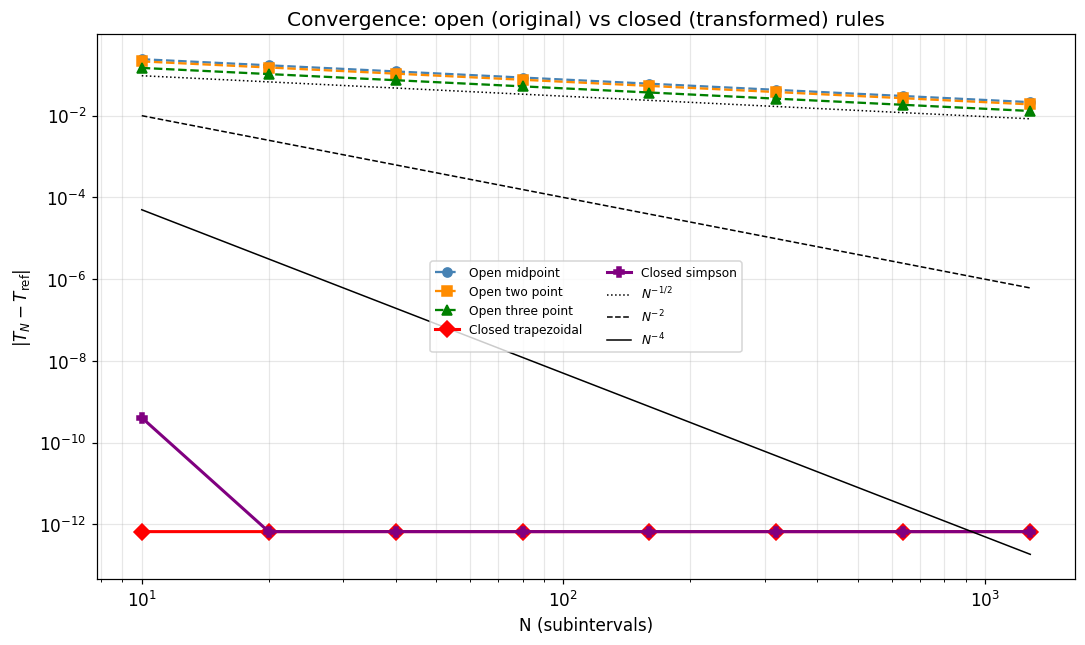

In [6]:
# Combined error plot
fig, ax = plt.subplots(figsize=(10, 6))
N_arr = np.array(N_vals, dtype=float)

style_open = {
    'midpoint':    ('o--', 'steelblue'),
    'two_point':   ('s--', 'darkorange'),
    'three_point': ('^--', 'green'),
}
style_closed = {
    'trapezoidal': ('D-', 'red'),
    'simpson':     ('P-', 'purple'),
}

for name, T_list in results.items():
    errs = np.abs(np.array(T_list) - T_ref)
    ls, col = style_open[name]
    ax.loglog(N_arr, errs, ls, color=col, lw=1.5, ms=6,
              label=f'Open {name.replace("_"," ")}')

for name, T_list in results_closed.items():
    errs = np.abs(np.array(T_list) - T_ref)
    ls, col = style_closed[name]
    ax.loglog(N_arr, errs, ls, color=col, lw=2, ms=7,
              label=f'Closed {name}')

ax.loglog(N_arr, 0.3*N_arr**(-0.5), 'k:',  lw=1, label=r'$N^{-1/2}$')
ax.loglog(N_arr, 1.0*N_arr**(-2.0), 'k--', lw=1, label=r'$N^{-2}$')
ax.loglog(N_arr, 0.5*N_arr**(-4.0), 'k-',  lw=1, label=r'$N^{-4}$')

ax.set_xlabel('N (subintervals)')
ax.set_ylabel(r'$|T_N - T_\mathrm{ref}|$')
ax.set_title('Convergence: open (original) vs closed (transformed) rules')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

**Discussion (Part 4, items 6 & 7):**

| Rule | Formal order | Observed (original) | Observed (transformed) |
|------|-------------|----------------------|------------------------|
| Midpoint / two-point / three-point | 2 / 2 / 4 | **½** | — |
| Trapezoidal | 2 | — | **≥ 10** (near machine precision at N=10!) |
| Simpson | 4 | — | **≥ 10** |

**Why the transformed integral converges so much better:**  
The substitution $x = A\sin\theta$ maps the algebraic singularity $(A-x)^{-1/2}$ to a removable  
singularity — the $\cos\theta$ factors cancel exactly. The resulting $g(\theta)$ is infinitely  
differentiable on $[0,\pi/2]$, so standard closed rules recover their full formal convergence order.  
In practice both closed rules hit floating-point precision ($\sim 10^{-13}$) already at $N=10$,  
making them essentially exact for this problem.